# BTUMQA-225K Phase 04: QAdp-PRUGTM Question-Only Clean-Metadata Four-Seeds Control

This notebook trains a full-budget question-only control for the clean QAdp-PRUGTM-Hybrid experiment.

It uses only the Phase 3B `question_embedding` tensor and excludes visual tokens, region auxiliary tensors, question descriptor IDs, and forbidden audit metadata.

Purpose: test whether the final QAdp-PRUGTM-Hybrid performance can be explained by question-text embeddings alone.

## Dual Environment Compatibility Setup & Install Required Libraries


In [1]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

import importlib
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


for import_name, pip_name in [
    ("matplotlib", "matplotlib"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("torch", "torch"),
    ("tqdm", "tqdm"),
]:
    ensure_package(import_name, pip_name)

## Mount Google Drive and Configure Paths

In [2]:
from pathlib import Path
import os
import time

try:
    from google.colab import drive
#     drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False


def ensure_drive_connection(project_dir: Path, mount_point: str = "/content/drive"):
    if not IN_COLAB:
        return

    def probe_path(target: Path):
        probe_target = target if target.exists() else target.parent
        return os.listdir(str(probe_target))

    try:
        probe_path(project_dir)
    except OSError as exc:
        if getattr(exc, "errno", None) != 107:
            raise
        print("Detected stale Google Drive mount. Remounting...")
        try:
            drive.flush_and_unmount()
            time.sleep(2)
        except Exception:
            pass
#         drive.mount(mount_point, force_remount=True)
        time.sleep(2)
        probe_path(project_dir)


# Updated project path to point to the new drive structure
PROJECT_DRIVE_DIR = PROJECT_ROOT

if not PROJECT_DRIVE_DIR.exists():
    PROJECT_DRIVE_DIR = Path.cwd()

ensure_drive_connection(PROJECT_DRIVE_DIR)

# Corrected paths: phase_3/p3a_brats_vqa_dataset/dataset_btumqa_225k
DATASET_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k"
if not DATASET_DIR.exists():
    local_dataset = Path.cwd() / "Dataset" / "dataset_btumqa_225k"
    if local_dataset.exists():
        DATASET_DIR = local_dataset

TRAIN_CSV_PATH = DATASET_DIR / "btumqa_225k_train.csv"
VAL_CSV_PATH = DATASET_DIR / "btumqa_225k_val.csv"
TEST_CSV_PATH = DATASET_DIR / "btumqa_225k_test.csv"
FULL_QA_PATH = DATASET_DIR / "btumqa_225k_qa_pairs.csv"

# Corrected paths: phase_3/p3b_text_preprocessing/dataset_btumqa_225k
PHASE3B_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3b_text_preprocessing" / "dataset_btumqa_225k"
EMBEDDINGS_TRAIN_PATH = PHASE3B_DIR / "text_embeddings_train.pt"
EMBEDDINGS_VAL_PATH = PHASE3B_DIR / "text_embeddings_val.pt"
EMBEDDINGS_TEST_PATH = PHASE3B_DIR / "text_embeddings_test.pt"
ANSWER_VOCAB_PATH = PHASE3B_DIR / "answer_vocab.json"
PHASE3B_CONFIG_PATH = PHASE3B_DIR / "phase3b_text_config.json"

# Corrected paths: phase_4/p4a_qgca_training
PHASE4_BASE_DIR = PROJECT_DRIVE_DIR / "phase_4" / "p4a_qgca_training"
PHASE4_CLEAN_METADATA_PARENT_DIR = PHASE4_BASE_DIR / "clean_metadata_training"
PHASE4_PARENT_DIR = PHASE4_CLEAN_METADATA_PARENT_DIR / "qadp_prugtm_question_only_btumqa_four_seeds"
FIGURES_DIR = PHASE4_PARENT_DIR / "figures"

# Corrected paths: phase_5/p5b_final_evaluation_ablation_calibration
PHASE5B_RESULT_DIR = (
    PROJECT_DRIVE_DIR
    / "phase_5"
    / "p5b_final_evaluation_ablation_calibration"
    / "btumqa_225k_clean_metadata_four_seeds_final_comparison"
)
if not PHASE5B_RESULT_DIR.exists():
    local_phase5b = Path.cwd() / "Res_Ck" / "5b_clean"
    if local_phase5b.exists():
        PHASE5B_RESULT_DIR = local_phase5b

FULL_QADP_ANSWER_TABLE_PATH = PHASE5B_RESULT_DIR / "tables" / "phase5b_clean_metadata_four_seeds_answer_backbone_table.csv"
SELECTED_QADP_EVIDENCE_PATH = PHASE5B_RESULT_DIR / "explanation_ready" / "selected_model_test_structured_evidence.csv"

PHASE4_PARENT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset dir:", DATASET_DIR)
print("Phase 3B dir:", PHASE3B_DIR)
print("Question-only output dir:", PHASE4_PARENT_DIR)
print("Full QAdp Phase 05B dir:", PHASE5B_RESULT_DIR)

Mounted at /content/drive
Dataset dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k
Phase 3B dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3b_text_preprocessing/dataset_btumqa_225k
Question-only output dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/qadp_prugtm_question_only_btumqa_four_seeds
Full QAdp Phase 05B dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison


## Configuration

In [4]:
RUN_SEEDS = [42, 1337, 2025, 3407]
TRAINABLE_SEEDS = RUN_SEEDS

# For smoke tests only:
# RUN_SEEDS = [42]
# DEBUG_MAX_ROWS_PER_SPLIT = 5000

DEBUG_MAX_ROWS_PER_SPLIT = None

MAX_EPOCHS = 50
MIN_EPOCHS_BEFORE_EARLY_STOP = 30
EARLY_STOPPING_PATIENCE = 8

BATCH_SIZE = 512
NUM_WORKERS = 0
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.25
LABEL_SMOOTHING = 0.03
USE_CLASS_WEIGHTS = True
GRAD_CLIP_NORM = 5.0

TEXT_EMBED_KEY_CANDIDATES = ["cls_last_hidden_state", "question_embedding", "pooler_output"]
TEXT_EMBED_DIM = 768
MODEL_DIM = 512
CLASSIFIER_HIDDEN_DIM = 1024

PHASE4_NOTEBOOK_NAME = "BrainTumorVQA_Phase_04_(BTUMQA_225K_QAdp_PRUGTM_Question_Only_Clean_Metadata_Four_Seeds)"
PHASE4_METHOD_NAME = "BTUMQA-225K-QAdp-PRUGTM-QuestionOnly-CleanMetadata-FourSeeds-Control"
PHASE4_MODEL_VARIANT = "qadp_prugtm_question_only_clean_metadata"

CLEAN_MODEL_INPUT_FIELDS = ["question_embedding"]
EXCLUDED_MODEL_INPUT_FIELDS = [
    "visual_tokens",
    "region_aux",
    "question_family_id",
    "question_style_id",
    "difficulty_level_id",
    "ambiguity_flag_id",
    "signal_gap_bucket_id",
    "region_target_primary_id",
    "region_target_secondary_id",
    "edema_area_pixels",
    "ncr_net_area_pixels",
    "enhancing_area_pixels",
    "tumor_area_pixels",
    "context_area_pixels",
    "global_area_pixels",
    "edema_uncertainty",
    "ncr_net_uncertainty",
    "enhancing_uncertainty",
    "tumor_uncertainty",
    "context_uncertainty",
    "global_uncertainty",
    "edema_weight",
    "ncr_net_weight",
    "enhancing_weight",
    "tumor_weight",
    "context_weight",
    "global_weight",
    "decision_rule_id",
    "label_provenance",
    "candidate_keep_reason",
]
AUDIT_REPORTING_FIELDS = [
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
]

print("Run seeds:", RUN_SEEDS)
print("Max epochs:", MAX_EPOCHS)
print("Model inputs:", CLEAN_MODEL_INPUT_FIELDS)
print("Excluded from prediction:", EXCLUDED_MODEL_INPUT_FIELDS)

Run seeds: [42, 1337, 2025, 3407]
Max epochs: 50
Model inputs: ['question_embedding']
Excluded from prediction: ['visual_tokens', 'region_aux', 'question_family_id', 'question_style_id', 'difficulty_level_id', 'ambiguity_flag_id', 'signal_gap_bucket_id', 'region_target_primary_id', 'region_target_secondary_id', 'edema_area_pixels', 'ncr_net_area_pixels', 'enhancing_area_pixels', 'tumor_area_pixels', 'context_area_pixels', 'global_area_pixels', 'edema_uncertainty', 'ncr_net_uncertainty', 'enhancing_uncertainty', 'tumor_uncertainty', 'context_uncertainty', 'global_uncertainty', 'edema_weight', 'ncr_net_weight', 'enhancing_weight', 'tumor_weight', 'context_weight', 'global_weight', 'decision_rule_id', 'label_provenance', 'candidate_keep_reason']


## Imports and Utility Helpers

In [5]:
from __future__ import annotations

import hashlib
import inspect
import json
import math
import platform
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "font.size": 11,
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def now_string() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def safe_torch_load(path: Path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def atomic_write_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    tmp_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    tmp_path.replace(path)


def atomic_write_csv(path: Path, df: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, index=False)
    tmp_path.replace(path)


def read_json(path: Path, default=None):
    if not path.exists():
        if default is not None:
            return default
        raise FileNotFoundError(path)
    return json.loads(path.read_text(encoding="utf-8"))


def select_text_embedding_key(payload: dict) -> str:
    for key in TEXT_EMBED_KEY_CANDIDATES:
        if key in payload:
            return key
    raise KeyError(f"No supported text embedding key found. Available keys: {list(payload.keys())}")


def compute_metrics(gold_ids, pred_ids) -> dict:
    return {
        "accuracy": float(accuracy_score(gold_ids, pred_ids)),
        "macro_f1": float(f1_score(gold_ids, pred_ids, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(gold_ids, pred_ids, average="weighted", zero_division=0)),
    }


def make_seed_paths(seed: int) -> dict:
    seed_dir = PHASE4_PARENT_DIR / f"seed_{seed}"
    paths = {
        "SEED_DIR": seed_dir,
        "CHECKPOINT_DIR": seed_dir / "checkpoints",
        "PREDICTIONS_DIR": seed_dir / "predictions",
        "TABLE_DIR": seed_dir / "tables",
        "REPORT_DIR": seed_dir / "reports",
        "DONE_DIR": seed_dir / "done",
    }
    paths["BEST_CHECKPOINT_PATH"] = paths["CHECKPOINT_DIR"] / "best_model.pt"
    paths["LAST_CHECKPOINT_PATH"] = paths["CHECKPOINT_DIR"] / "last_model.pt"
    paths["TRAINING_HISTORY_PATH"] = paths["TABLE_DIR"] / "training_history.csv"
    paths["VAL_PREDICTIONS_PATH"] = paths["PREDICTIONS_DIR"] / "val_predictions.csv"
    paths["TEST_PREDICTIONS_PATH"] = paths["PREDICTIONS_DIR"] / "test_predictions.csv"
    paths["FINAL_REPORT_PATH"] = paths["REPORT_DIR"] / "final_report.json"
    paths["DONE_PATH"] = paths["DONE_DIR"] / "seed_complete.json"
    for key in ["CHECKPOINT_DIR", "PREDICTIONS_DIR", "TABLE_DIR", "REPORT_DIR", "DONE_DIR"]:
        paths[key].mkdir(parents=True, exist_ok=True)
    return paths


def seed_artifacts_complete(paths: dict) -> tuple[bool, list[str]]:
    required = [
        paths["DONE_PATH"],
        paths["FINAL_REPORT_PATH"],
        paths["BEST_CHECKPOINT_PATH"],
        paths["VAL_PREDICTIONS_PATH"],
        paths["TEST_PREDICTIONS_PATH"],
        paths["TRAINING_HISTORY_PATH"],
    ]
    missing = [str(path) for path in required if not Path(path).exists()]
    return len(missing) == 0, missing


def summary_row_from_final_report(seed: int, paths: dict) -> dict:
    report = read_json(paths["FINAL_REPORT_PATH"])
    val_metrics = report.get("val_metrics", {})
    test_metrics = report.get("test_metrics", {})
    row = {
        "seed": int(seed),
        "best_epoch": int(report.get("best_epoch", -1)),
        "elapsed_minutes": float(report.get("elapsed_minutes", 0.0)),
        "run_status": "skipped_completed",
    }
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    row.update({f"test_{k}": v for k, v in test_metrics.items()})
    row.update(
        {
            "best_checkpoint": str(paths["BEST_CHECKPOINT_PATH"]),
            "training_history_path": str(paths["TRAINING_HISTORY_PATH"]),
            "val_predictions_path": str(paths["VAL_PREDICTIONS_PATH"]),
            "test_predictions_path": str(paths["TEST_PREDICTIONS_PATH"]),
        }
    )
    return row


def assert_question_only_forward_signature(model: nn.Module) -> dict:
    sig = inspect.signature(model.forward)
    params = list(sig.parameters.keys())
    forbidden = [name for name in EXCLUDED_MODEL_INPUT_FIELDS if name in params]
    if forbidden:
        raise AssertionError(f"Forbidden model inputs appear in forward signature: {forbidden}")
    if params != ["question_embedding"]:
        raise AssertionError(f"Question-only forward signature must be ['question_embedding'], found {params}")
    return {"forward_parameters": params, "passed": True}


print("Device:", DEVICE)
print("AMP enabled:", USE_AMP)

Device: cuda
AMP enabled: True


## Input Policy and Aux-Source Confirmation Report

In [6]:
input_policy_report = {
    "created_at": now_string(),
    "phase": "Phase 04 question-only clean-metadata control",
    "policy_name": "strict_question_embedding_only_control",
    "model_input_fields": CLEAN_MODEL_INPUT_FIELDS,
    "excluded_model_input_fields": EXCLUDED_MODEL_INPUT_FIELDS,
    "audit_reporting_fields_retained_only_for_metrics": AUDIT_REPORTING_FIELDS,
    "question_embedding_source": {
        "phase": "Phase 3B text preprocessing",
        "source_text": "df['question'] only",
        "encoder": "BiomedBERT family encoder saved in Phase 3B embedding payloads",
        "metadata_concatenated_into_text": False,
    },
    "full_qadp_aux_source_confirmation": {
        "visual_tokens": "Phase 2A original visual tokens from imaging pipeline.",
        "region_aux": (
            "Phase 2C tensor built from Phase 2A visual-token alignment and Phase 2B MC-dropout "
            "region uncertainty/region processing. It is loaded from Phase 2C payloads, not directly "
            "from BTUMQA CSV raw audit columns."
        ),
        "routing_fields": [
            "phase2c_file",
            "slice_index_in_ugtm_file",
        ],
        "routing_field_policy": "Used only to locate the correct visual/aux tensor rows; not embedded as model features.",
        "csv_audit_fields_not_direct_model_inputs": [
            "question_family",
            "question_style",
            "difficulty_level",
            "ambiguity_flag",
            "signal_gap_bucket",
            "region_target_primary",
            "region_target_secondary",
            "raw area/uncertainty/weight columns",
            "decision_rule_id",
            "label_provenance",
            "candidate_keep_reason",
        ],
    },
    "paper_safe_interpretation": [
        "This control tests whether question text embeddings alone can explain full QAdp performance.",
        "It does not claim the dataset is bias-free.",
        "A large gap between full QAdp and this question-only control supports the value of visual and uncertainty-guided inputs.",
    ],
}

atomic_write_json(PHASE4_PARENT_DIR / "reports" / "question_only_input_policy_report.json", input_policy_report)
print(json.dumps(input_policy_report, indent=2)[:4000])

{
  "created_at": "2026-05-14 18:05:45",
  "phase": "Phase 04 question-only clean-metadata control",
  "policy_name": "strict_question_embedding_only_control",
  "model_input_fields": [
    "question_embedding"
  ],
  "excluded_model_input_fields": [
    "visual_tokens",
    "region_aux",
    "question_family_id",
    "question_style_id",
    "difficulty_level_id",
    "ambiguity_flag_id",
    "signal_gap_bucket_id",
    "region_target_primary_id",
    "region_target_secondary_id",
    "edema_area_pixels",
    "ncr_net_area_pixels",
    "enhancing_area_pixels",
    "tumor_area_pixels",
    "context_area_pixels",
    "global_area_pixels",
    "edema_uncertainty",
    "ncr_net_uncertainty",
    "enhancing_uncertainty",
    "tumor_uncertainty",
    "context_uncertainty",
    "global_uncertainty",
    "edema_weight",
    "ncr_net_weight",
    "enhancing_weight",
    "tumor_weight",
    "context_weight",
    "global_weight",
    "decision_rule_id",
    "label_provenance",
    "candidate_kee

## Load Dataset, Embeddings, and Vocabularies

In [7]:
required_paths = [
    TRAIN_CSV_PATH,
    VAL_CSV_PATH,
    TEST_CSV_PATH,
    EMBEDDINGS_TRAIN_PATH,
    EMBEDDINGS_VAL_PATH,
    EMBEDDINGS_TEST_PATH,
    ANSWER_VOCAB_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required inputs:\n" + "\n".join(missing_paths))

REQUIRED_CSV_COLUMNS = [
    "qa_id",
    "split",
    "patient_id",
    "slice_id",
    "unique_id",
    "question",
    "answer",
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "region_target_primary",
    "region_target_secondary",
    "signal_gap_bucket",
]


def apply_debug_limit(df: pd.DataFrame, split_name: str):
    if DEBUG_MAX_ROWS_PER_SPLIT is None:
        return df.reset_index(drop=True)
    limited = df.iloc[:DEBUG_MAX_ROWS_PER_SPLIT].copy().reset_index(drop=True)
    print(f"[DEBUG] {split_name}: limited rows from {len(df)} to {len(limited)}")
    return limited


def load_split_csv(path: Path, split_name: str):
    df = pd.read_csv(path, dtype=str).fillna("")
    missing = [col for col in REQUIRED_CSV_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"{split_name} missing required columns: {missing}")
    df["patient_id"] = df["patient_id"].astype(str).str.zfill(5)
    df["slice_id"] = df["slice_id"].astype(str).str.zfill(3)
    df = apply_debug_limit(df, split_name)
    print(f"{split_name}: rows={len(df):,}")
    return df


def load_embedding_payload(path: Path, df: pd.DataFrame, split_name: str):
    payload = safe_torch_load(path, map_location="cpu")
    text_key = select_text_embedding_key(payload)
    use_rows = len(df)
    if len(payload["qa_id"]) < use_rows:
        raise ValueError(f"{split_name} embedding rows smaller than CSV rows: {len(payload['qa_id'])} < {use_rows}")
    embedding_qa_ids = [str(x) for x in payload["qa_id"][:use_rows]]
    csv_qa_ids = df["qa_id"].astype(str).tolist()
    if embedding_qa_ids != csv_qa_ids:
        raise ValueError(f"{split_name} qa_id order mismatch between CSV and embeddings.")
    result = {
        "qa_id": embedding_qa_ids,
        "question_embedding": payload[text_key][:use_rows].float().contiguous(),
        "answer_id": payload["answer_id"][:use_rows].long().contiguous(),
        "text_key": text_key,
    }
    print(f"{split_name} embeddings: key={text_key}, shape={tuple(result['question_embedding'].shape)}")
    return result


answer_vocab = read_json(ANSWER_VOCAB_PATH)
idx_to_answer = {idx: answer for answer, idx in answer_vocab.items()}

df_train = load_split_csv(TRAIN_CSV_PATH, "train")
df_val = load_split_csv(VAL_CSV_PATH, "val")
df_test = load_split_csv(TEST_CSV_PATH, "test")

emb_train = load_embedding_payload(EMBEDDINGS_TRAIN_PATH, df_train, "train")
emb_val = load_embedding_payload(EMBEDDINGS_VAL_PATH, df_val, "val")
emb_test = load_embedding_payload(EMBEDDINGS_TEST_PATH, df_test, "test")

if emb_train["question_embedding"].shape[1] != TEXT_EMBED_DIM:
    TEXT_EMBED_DIM = int(emb_train["question_embedding"].shape[1])
    print("Adjusted TEXT_EMBED_DIM:", TEXT_EMBED_DIM)

load_manifest = {
    "created_at": now_string(),
    "dataset_dir": str(DATASET_DIR),
    "phase3b_dir": str(PHASE3B_DIR),
    "train_rows": int(len(df_train)),
    "val_rows": int(len(df_val)),
    "test_rows": int(len(df_test)),
    "answer_classes": int(len(answer_vocab)),
    "text_embedding_key": emb_train["text_key"],
    "question_embedding_shape": list(emb_train["question_embedding"].shape),
    "dataset_sha256": sha256_file(FULL_QA_PATH) if FULL_QA_PATH.exists() else None,
}
atomic_write_json(PHASE4_PARENT_DIR / "reports" / "question_only_load_manifest.json", load_manifest)
print(json.dumps(load_manifest, indent=2))

train: rows=157,500
val: rows=33,750
test: rows=33,750
train embeddings: key=cls_last_hidden_state, shape=(157500, 768)
val embeddings: key=cls_last_hidden_state, shape=(33750, 768)
test embeddings: key=cls_last_hidden_state, shape=(33750, 768)
{
  "created_at": "2026-05-14 18:06:39",
  "dataset_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k",
  "phase3b_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3b_text_preprocessing/dataset_btumqa_225k",
  "train_rows": 157500,
  "val_rows": 33750,
  "test_rows": 33750,
  "answer_classes": 23,
  "text_embedding_key": "cls_last_hidden_state",
  "question_embedding_shape": [
    157500,
    768
  ],
  "dataset_sha256": "d4a6b8b5b7f7124a583380fa63e232c4aa5a0728e93e570d3f82229926809966"
}


## Dataset and Question-Only Model

In [8]:
class QuestionOnlyBTUMQADataset(Dataset):
    def __init__(self, df: pd.DataFrame, embedding_payload: dict):
        self.df = df.reset_index(drop=True)
        self.qa_ids = embedding_payload["qa_id"]
        self.question_embeddings = embedding_payload["question_embedding"].float().contiguous()
        self.answer_ids = embedding_payload["answer_id"].long().contiguous()

        self.unique_ids = self.df["unique_id"].astype(str).tolist()
        self.answer_texts = self.df["answer"].astype(str).tolist()
        self.audit_fields = {
            field: self.df[field].astype(str).tolist()
            for field in AUDIT_REPORTING_FIELDS
            if field in self.df.columns
        }

        if len(self.df) != len(self.qa_ids):
            raise ValueError("Dataset length mismatch between CSV rows and embedding rows.")

    def __len__(self):
        return len(self.qa_ids)

    def __getitem__(self, index: int):
        item = {
            "qa_id": self.qa_ids[index],
            "unique_id": self.unique_ids[index],
            "question_embedding": self.question_embeddings[index],
            "answer_id": self.answer_ids[index],
            "answer_text": self.answer_texts[index],
        }
        for field, values in self.audit_fields.items():
            item[field] = values[index]
        return item


def collate_question_only_batch(batch: list[dict]) -> dict:
    out = {
        "question_embedding": torch.stack([item["question_embedding"] for item in batch], dim=0),
        "answer_id": torch.stack([item["answer_id"] for item in batch], dim=0),
    }
    for key in batch[0].keys():
        if key not in out:
            out[key] = [item[key] for item in batch]
    return out


def build_class_weights(answer_ids: torch.Tensor, num_classes: int):
    counts = torch.bincount(answer_ids, minlength=num_classes).float()
    weights = counts.sum() / counts.clamp_min(1.0)
    weights = weights / weights.mean()
    return weights


class QAdpQuestionOnlyControlModel(nn.Module):
    def __init__(self, text_embed_dim: int, model_dim: int, classifier_hidden_dim: int, dropout: float, num_answers: int):
        super().__init__()
        self.clean_metadata_policy = {
            "model_inputs": CLEAN_MODEL_INPUT_FIELDS,
            "excluded_model_inputs": EXCLUDED_MODEL_INPUT_FIELDS,
            "audit_reporting_fields": AUDIT_REPORTING_FIELDS,
        }
        self.question_proj = nn.Sequential(
            nn.Linear(text_embed_dim, model_dim),
            nn.LayerNorm(model_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(model_dim, model_dim),
            nn.LayerNorm(model_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Linear(model_dim * 4, classifier_hidden_dim),
            nn.LayerNorm(classifier_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden_dim, classifier_hidden_dim // 2),
            nn.LayerNorm(classifier_hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden_dim // 2, num_answers),
        )

    def forward(self, question_embedding):
        q = self.question_proj(question_embedding)
        classifier_input = torch.cat([q, q * q, torch.abs(q), torch.tanh(q)], dim=-1)
        logits = self.classifier(classifier_input)
        return {
            "logits": logits,
            "question_features": q,
        }


train_dataset = QuestionOnlyBTUMQADataset(df_train, emb_train)
val_dataset = QuestionOnlyBTUMQADataset(df_val, emb_val)
test_dataset = QuestionOnlyBTUMQADataset(df_test, emb_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_question_only_batch, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_question_only_batch, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_question_only_batch, pin_memory=torch.cuda.is_available())

class_weights = build_class_weights(emb_train["answer_id"], len(answer_vocab))

sample_batch = next(iter(train_loader))
print("Sample question_embedding:", tuple(sample_batch["question_embedding"].shape))
print("Sample answer_id:", tuple(sample_batch["answer_id"].shape))
print("Class weights:", tuple(class_weights.shape))

Sample question_embedding: (512, 768)
Sample answer_id: (512,)
Class weights: (23,)


## Training and Evaluation Functions

In [10]:
def move_batch_to_device(batch: dict) -> dict:
    return {
        "question_embedding": batch["question_embedding"].to(DEVICE, non_blocking=True).float(),
        "answer_id": batch["answer_id"].to(DEVICE, non_blocking=True).long(),
        "qa_id": batch["qa_id"],
        "unique_id": batch["unique_id"],
        "answer_text": batch["answer_text"],
        **{field: batch[field] for field in AUDIT_REPORTING_FIELDS if field in batch},
    }


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    losses = []
    gold_ids = []
    pred_ids = []
    progress = tqdm(loader, desc="train", leave=False, dynamic_ncols=True)
    for raw_batch in progress:
        batch = move_batch_to_device(raw_batch)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            outputs = model(question_embedding=batch["question_embedding"])
            logits = outputs["logits"]
            loss = criterion(logits, batch["answer_id"])
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        pred = logits.detach().argmax(dim=-1)
        losses.append(float(loss.item()) * batch["answer_id"].shape[0])
        gold_ids.extend(batch["answer_id"].detach().cpu().tolist())
        pred_ids.extend(pred.detach().cpu().tolist())
        progress.set_postfix(loss=float(np.sum(losses) / max(len(gold_ids), 1)))

    metrics = compute_metrics(gold_ids, pred_ids)
    metrics["loss"] = float(np.sum(losses) / max(len(gold_ids), 1))
    return metrics


@torch.no_grad()
def evaluate_model(model, loader, criterion, split_name: str, return_predictions: bool = False):
    model.eval()
    losses = []
    gold_ids = []
    pred_ids = []
    confidence_values = []
    rows = []

    for raw_batch in tqdm(loader, desc=f"eval-{split_name}", leave=False, dynamic_ncols=True):
        batch = move_batch_to_device(raw_batch)
        outputs = model(question_embedding=batch["question_embedding"])
        logits = outputs["logits"]
        loss = criterion(logits, batch["answer_id"])
        probs = torch.softmax(logits, dim=-1)
        confidence, pred = probs.max(dim=-1)

        batch_gold = batch["answer_id"].detach().cpu().tolist()
        batch_pred = pred.detach().cpu().tolist()
        batch_conf = confidence.detach().cpu().tolist()

        losses.append(float(loss.item()) * len(batch_gold))
        gold_ids.extend(batch_gold)
        pred_ids.extend(batch_pred)
        confidence_values.extend(batch_conf)

        if return_predictions:
            for idx in range(len(batch_gold)):
                row = {
                    "qa_id": batch["qa_id"][idx],
                    "unique_id": batch["unique_id"][idx],
                    "split": split_name,
                    "gold_answer": idx_to_answer[int(batch_gold[idx])],
                    "predicted_answer": idx_to_answer[int(batch_pred[idx])],
                    "is_correct": int(batch_gold[idx] == batch_pred[idx]),
                    "confidence": float(batch_conf[idx]),
                }
                for field in AUDIT_REPORTING_FIELDS:
                    if field in batch:
                        row[field] = batch[field][idx]
                rows.append(row)

    metrics = compute_metrics(gold_ids, pred_ids)
    metrics["loss"] = float(np.sum(losses) / max(len(gold_ids), 1))
    metrics["mean_confidence"] = float(np.mean(confidence_values)) if confidence_values else float("nan")
    prediction_df = pd.DataFrame(rows) if return_predictions else pd.DataFrame()
    return metrics, prediction_df


def save_checkpoint(path: Path, model, optimizer, scheduler, epoch: int, best_metric: float, history: list[dict], seed: int, extra: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "epoch": epoch,
            "best_metric": best_metric,
            "history": history,
            "seed": seed,
            "extra": extra,
        },
        path,
    )

## Train Four-Seed Question-Only Control

In [11]:
RUN_EXECUTION_SUMMARY = []

for run_seed in RUN_SEEDS:
    print("=" * 100)
    print(f"Starting question-only control seed: {run_seed}")
    seed_everything(run_seed)
    paths = make_seed_paths(run_seed)
    complete, missing_artifacts = seed_artifacts_complete(paths)
    if complete:
        print(f"Seed {run_seed} already complete. Skipping training and loading saved final report.")
        RUN_EXECUTION_SUMMARY.append(summary_row_from_final_report(run_seed, paths))
        continue
    if missing_artifacts:
        print(f"Seed {run_seed} is incomplete; training this seed. Missing required artifacts:")
        for missing_path in missing_artifacts:
            print(" -", missing_path)

    phase4_config = {
        "created_at": now_string(),
        "phase": "Phase 04 QAdp-PRUGTM question-only clean-metadata control",
        "notebook": PHASE4_NOTEBOOK_NAME,
        "method_name": PHASE4_METHOD_NAME,
        "model_variant": PHASE4_MODEL_VARIANT,
        "seed": run_seed,
        "model_input_fields": CLEAN_MODEL_INPUT_FIELDS,
        "excluded_model_input_fields": EXCLUDED_MODEL_INPUT_FIELDS,
        "audit_reporting_fields": AUDIT_REPORTING_FIELDS,
        "max_epochs": MAX_EPOCHS,
        "min_epochs_before_early_stop": MIN_EPOCHS_BEFORE_EARLY_STOP,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "dropout": DROPOUT,
        "label_smoothing": LABEL_SMOOTHING,
        "use_class_weights": USE_CLASS_WEIGHTS,
        "device": str(DEVICE),
    }
    atomic_write_json(paths["REPORT_DIR"] / "phase4_question_only_config.json", phase4_config)

    model = QAdpQuestionOnlyControlModel(
        text_embed_dim=TEXT_EMBED_DIM,
        model_dim=MODEL_DIM,
        classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
        dropout=DROPOUT,
        num_answers=len(answer_vocab),
    ).to(DEVICE)
    forward_signature_check = assert_question_only_forward_signature(model)
    print("Forward signature:", forward_signature_check)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE) if USE_CLASS_WEIGHTS else None,
        label_smoothing=LABEL_SMOOTHING,
    )
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6)
    scaler = GradScaler(enabled=USE_AMP)

    with torch.no_grad():
        smoke = model(question_embedding=sample_batch["question_embedding"].to(DEVICE).float())
    assert tuple(smoke["logits"].shape) == (sample_batch["question_embedding"].shape[0], len(answer_vocab))
    print("Smoke test logits shape:", tuple(smoke["logits"].shape))

    best_metric = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []
    started_at = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        print(f"\nSeed {run_seed} | Epoch {epoch}/{MAX_EPOCHS}")
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_metrics, _ = evaluate_model(model, val_loader, criterion, "val", return_predictions=False)
        scheduler.step(val_metrics["macro_f1"])

        row = {
            "seed": run_seed,
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)
        atomic_write_csv(paths["TRAINING_HISTORY_PATH"], pd.DataFrame(history))

        improved = val_metrics["macro_f1"] > best_metric
        if improved:
            best_metric = val_metrics["macro_f1"]
            best_epoch = epoch
            epochs_without_improvement = 0
            save_checkpoint(
                paths["BEST_CHECKPOINT_PATH"],
                model,
                optimizer,
                scheduler,
                epoch,
                best_metric,
                history,
                run_seed,
                {"forward_signature_check": forward_signature_check},
            )
            print(f"New best val Macro-F1: {best_metric:.6f}")
        else:
            epochs_without_improvement += 1

        save_checkpoint(
            paths["LAST_CHECKPOINT_PATH"],
            model,
            optimizer,
            scheduler,
            epoch,
            best_metric,
            history,
            run_seed,
            {"forward_signature_check": forward_signature_check},
        )

        print(
            f"train_acc={train_metrics['accuracy']:.4f} train_macro_f1={train_metrics['macro_f1']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"no_improve={epochs_without_improvement}"
        )

        if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    best_payload = safe_torch_load(paths["BEST_CHECKPOINT_PATH"], map_location=DEVICE)
    model.load_state_dict(best_payload["model_state_dict"])

    val_metrics, val_predictions = evaluate_model(model, val_loader, criterion, "val", return_predictions=True)
    test_metrics, test_predictions = evaluate_model(model, test_loader, criterion, "test", return_predictions=True)

    atomic_write_csv(paths["VAL_PREDICTIONS_PATH"], val_predictions)
    atomic_write_csv(paths["TEST_PREDICTIONS_PATH"], test_predictions)

    elapsed_minutes = round((time.time() - started_at) / 60.0, 2)
    final_report = {
        "finished_at": now_string(),
        "seed": run_seed,
        "phase": "Phase 04 QAdp-PRUGTM question-only clean-metadata control",
        "model_variant": PHASE4_MODEL_VARIANT,
        "model_input_fields": CLEAN_MODEL_INPUT_FIELDS,
        "excluded_model_input_fields": EXCLUDED_MODEL_INPUT_FIELDS,
        "best_epoch": int(best_epoch),
        "best_val_macro_f1": float(best_metric),
        "elapsed_minutes": elapsed_minutes,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "paths": {
            "best_checkpoint": str(paths["BEST_CHECKPOINT_PATH"]),
            "training_history": str(paths["TRAINING_HISTORY_PATH"]),
            "val_predictions": str(paths["VAL_PREDICTIONS_PATH"]),
            "test_predictions": str(paths["TEST_PREDICTIONS_PATH"]),
        },
        "paper_safe_interpretation": (
            "This is a full-budget question-only control. It measures text-only shortcut risk and is not a final VQA model."
        ),
    }
    atomic_write_json(paths["FINAL_REPORT_PATH"], final_report)
    atomic_write_json(paths["DONE_PATH"], {"status": "complete", "finished_at": now_string(), "report": str(paths["FINAL_REPORT_PATH"])})

    summary_row = {
        "seed": run_seed,
        "best_epoch": int(best_epoch),
        "elapsed_minutes": elapsed_minutes,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
        "best_checkpoint": str(paths["BEST_CHECKPOINT_PATH"]),
        "training_history_path": str(paths["TRAINING_HISTORY_PATH"]),
        "val_predictions_path": str(paths["VAL_PREDICTIONS_PATH"]),
        "test_predictions_path": str(paths["TEST_PREDICTIONS_PATH"]),
        "run_status": "trained",
    }
    RUN_EXECUTION_SUMMARY.append(summary_row)

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

run_summary_df = pd.DataFrame(RUN_EXECUTION_SUMMARY).sort_values(
    ["test_macro_f1", "test_accuracy", "test_weighted_f1"],
    ascending=[False, False, False],
)
atomic_write_csv(PHASE4_PARENT_DIR / "tables" / "question_only_four_seed_run_summary.csv", run_summary_df)
display(run_summary_df)

Starting question-only control seed: 42
Seed 42 is incomplete; training this seed. Missing required artifacts:
 - /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/qadp_prugtm_question_only_btumqa_four_seeds/seed_42/done/seed_complete.json
 - /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/qadp_prugtm_question_only_btumqa_four_seeds/seed_42/reports/final_report.json
 - /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/qadp_prugtm_question_only_btumqa_four_seeds/seed_42/checkpoints/best_model.pt
 - /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/qadp_prugtm_question_only_btumqa_four_seeds/seed_42/p

train:   0%|          | 0/308 [00:00<?, ?it/s]

eval-val:   0%|          | 0/66 [00:00<?, ?it/s]

New best val Macro-F1: 0.248043
train_acc=0.3443 train_macro_f1=0.2728 | val_acc=0.4762 val_macro_f1=0.2480 | no_improve=0

Seed 42 | Epoch 2/50


train:   0%|          | 0/308 [00:00<?, ?it/s]

...

eval-val:   0%|          | 0/66 [00:00<?, ?it/s]

train_acc=0.3748 train_macro_f1=0.2935 | val_acc=0.3703 val_macro_f1=0.2672 | no_improve=8
Early stopping at epoch 33. Best epoch: 25


eval-val:   0%|          | 0/66 [00:00<?, ?it/s]

eval-test:   0%|          | 0/66 [00:00<?, ?it/s]

,seed,best_epoch,elapsed_minutes,val_accuracy,val_macro_f1,val_weighted_f1,val_loss,val_mean_confidence,test_accuracy,test_macro_f1,test_weighted_f1,test_loss,test_mean_confidence,best_checkpoint,training_history_path,val_predictions_path,test_predictions_path,run_status
2,2025,28,3.97,0.442726,0.295398,0.437455,1.628809,0.395386,0.436119,0.289929,0.433657,1.634092,0.395317,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,trained
1,1337,30,4.19,0.406222,0.290471,0.414351,1.628522,0.391971,0.400267,0.287535,0.411526,1.633642,0.391872,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,trained
0,42,25,3.49,0.433896,0.291693,0.428744,1.628045,0.393408,0.425985,0.285053,0.422956,1.633392,0.393322,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,trained
3,3407,25,3.71,0.433156,0.288514,0.424923,1.628822,0.395061,0.427289,0.283494,0.421755,1.633731,0.395021,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,trained


## Aggregate Four-Seed Results and Compare With Full QAdp

In [12]:
run_summary_path = PHASE4_PARENT_DIR / "tables" / "question_only_four_seed_run_summary.csv"
run_summary_df = pd.read_csv(run_summary_path)

agg = {
    "model_key": "qadp_prugtm_question_only_clean",
    "model_label": "QAdp-PRUGTM Question-Only",
    "num_runs": int(len(run_summary_df)),
    "model_input_fields": "|".join(CLEAN_MODEL_INPUT_FIELDS),
}
for metric in ["accuracy", "macro_f1", "weighted_f1", "loss", "mean_confidence"]:
    col = f"test_{metric}"
    agg[f"{col}_mean"] = float(run_summary_df[col].mean())
    agg[f"{col}_std"] = float(run_summary_df[col].std(ddof=0))

question_only_agg_df = pd.DataFrame([agg])
atomic_write_csv(PHASE4_PARENT_DIR / "tables" / "question_only_four_seed_aggregated_metrics.csv", question_only_agg_df)

comparison_rows = [agg.copy()]

full_qadp_row = None
if FULL_QADP_ANSWER_TABLE_PATH.exists():
    answer_table = pd.read_csv(FULL_QADP_ANSWER_TABLE_PATH)
    matches = answer_table[answer_table["backbone_key"].astype(str) == "qadp_prugtm_hybrid_clean"]
    if len(matches):
        src = matches.iloc[0].to_dict()
        full_qadp_row = {
            "model_key": "qadp_prugtm_hybrid_clean",
            "model_label": "Full QAdp-PRUGTM-Hybrid",
            "num_runs": int(src.get("num_runs", 4)),
            "model_input_fields": "question_embedding|visual_tokens|region_aux",
            "test_accuracy_mean": float(src["test_accuracy_mean"]),
            "test_accuracy_std": float(src.get("test_accuracy_std", 0.0)),
            "test_macro_f1_mean": float(src["test_macro_f1_mean"]),
            "test_macro_f1_std": float(src.get("test_macro_f1_std", 0.0)),
            "test_weighted_f1_mean": float(src["test_weighted_f1_mean"]),
            "test_weighted_f1_std": float(src.get("test_weighted_f1_std", 0.0)),
            "test_loss_mean": np.nan,
            "test_loss_std": np.nan,
            "test_mean_confidence_mean": np.nan,
            "test_mean_confidence_std": np.nan,
        }
        comparison_rows.append(full_qadp_row)

selected_qadp_row = None
if SELECTED_QADP_EVIDENCE_PATH.exists():
    selected = pd.read_csv(SELECTED_QADP_EVIDENCE_PATH, dtype={"qa_id": str, "unique_id": str})
    gold_col = "gold_answer" if "gold_answer" in selected.columns else "answer"
    if gold_col in selected.columns and "predicted_answer" in selected.columns:
        selected_metrics = compute_metrics(selected[gold_col].astype(str), selected["predicted_answer"].astype(str))
        selected_qadp_row = {
            "model_key": "qadp_prugtm_hybrid_qcur_selected_seed",
            "model_label": "Selected QAdp-PRUGTM-Hybrid + Q-CUR",
            "num_runs": 1,
            "model_input_fields": "question_embedding|visual_tokens|region_aux",
            "test_accuracy_mean": selected_metrics["accuracy"],
            "test_accuracy_std": 0.0,
            "test_macro_f1_mean": selected_metrics["macro_f1"],
            "test_macro_f1_std": 0.0,
            "test_weighted_f1_mean": selected_metrics["weighted_f1"],
            "test_weighted_f1_std": 0.0,
            "test_loss_mean": np.nan,
            "test_loss_std": np.nan,
            "test_mean_confidence_mean": float(pd.to_numeric(selected.get("qcur_confidence"), errors="coerce").mean()) if "qcur_confidence" in selected.columns else np.nan,
            "test_mean_confidence_std": 0.0,
        }
        comparison_rows.append(selected_qadp_row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_macro_f1_mean", ascending=False)
atomic_write_csv(PHASE4_PARENT_DIR / "tables" / "question_only_vs_full_qadp_comparison.csv", comparison_df)

gap_rows = []
for ref in [full_qadp_row, selected_qadp_row]:
    if ref is None:
        continue
    for metric in ["accuracy", "macro_f1", "weighted_f1"]:
        gap_rows.append(
            {
                "reference_model_key": ref["model_key"],
                "reference_model_label": ref["model_label"],
                "metric": metric,
                "full_or_selected_qadp_value": float(ref[f"test_{metric}_mean"]),
                "question_only_value": float(agg[f"test_{metric}_mean"]),
                "qadp_minus_question_only": float(ref[f"test_{metric}_mean"] - agg[f"test_{metric}_mean"]),
            }
        )
gap_df = pd.DataFrame(gap_rows)
atomic_write_csv(PHASE4_PARENT_DIR / "tables" / "question_only_vs_full_qadp_gap_metrics.csv", gap_df)

interpretation_report = {
    "finished_at": now_string(),
    "phase": "Question-only full-budget control vs full QAdp comparison",
    "question_only_aggregated": agg,
    "comparison_rows": comparison_df.to_dict(orient="records"),
    "gap_metrics": gap_df.to_dict(orient="records"),
    "interpretation_rules": [
        "A large gap from full QAdp to question-only indicates final performance is not explained by question text alone.",
        "This does not prove the benchmark is bias-free.",
        "Question-only performance quantifies residual text-only shortcut risk under a full-budget neural control.",
    ],
}
atomic_write_json(PHASE4_PARENT_DIR / "reports" / "question_only_vs_full_qadp_interpretation.json", interpretation_report)

display(comparison_df)
display(gap_df)

,model_key,model_label,num_runs,model_input_fields,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,test_weighted_f1_std,test_loss_mean,test_loss_std,test_mean_confidence_mean,test_mean_confidence_std
2,qadp_prugtm_hybrid_qcur_selected_seed,Selected QAdp-PRUGTM-Hybrid + Q-CUR,1,question_embedding|visual_tokens|region_aux,0.929274,0.000000,0.920041,0.000000,0.931475,0.000000,NaN,NaN,0.932526,0.000000
1,qadp_prugtm_hybrid_clean,Full QAdp-PRUGTM-Hybrid,4,question_embedding|visual_tokens|region_aux,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,NaN,NaN,NaN,NaN
0,qadp_prugtm_question_only_clean,QAdp-PRUGTM Question-Only,4,question_embedding,0.422415,0.013368,0.286503,0.002448,0.422474,0.007837,1.633714,0.000251,0.393883,0.001388


,reference_model_key,reference_model_label,metric,full_or_selected_qadp_value,question_only_value,qadp_minus_question_only
0,qadp_prugtm_hybrid_clean,Full QAdp-PRUGTM-Hybrid,accuracy,0.911430,0.422415,0.489015
1,qadp_prugtm_hybrid_clean,Full QAdp-PRUGTM-Hybrid,macro_f1,0.907572,0.286503,0.621070
2,qadp_prugtm_hybrid_clean,Full QAdp-PRUGTM-Hybrid,weighted_f1,0.914174,0.422474,0.491700
3,qadp_prugtm_hybrid_qcur_selected_seed,Selected QAdp-PRUGTM-Hybrid + Q-CUR,accuracy,0.929274,0.422415,0.506859
4,qadp_prugtm_hybrid_qcur_selected_seed,Selected QAdp-PRUGTM-Hybrid + Q-CUR,macro_f1,0.920041,0.286503,0.633538
5,qadp_prugtm_hybrid_qcur_selected_seed,Selected QAdp-PRUGTM-Hybrid + Q-CUR,weighted_f1,0.931475,0.422474,0.509002


## Core Visual Comparison Figures

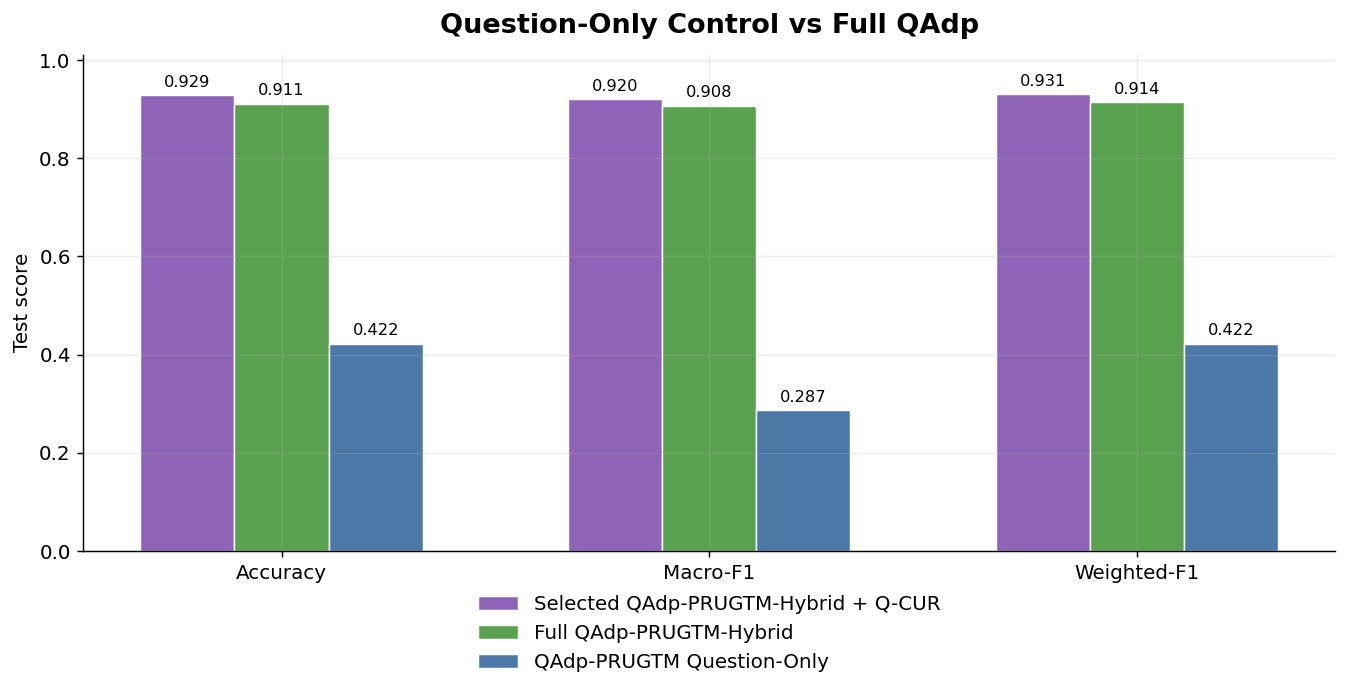

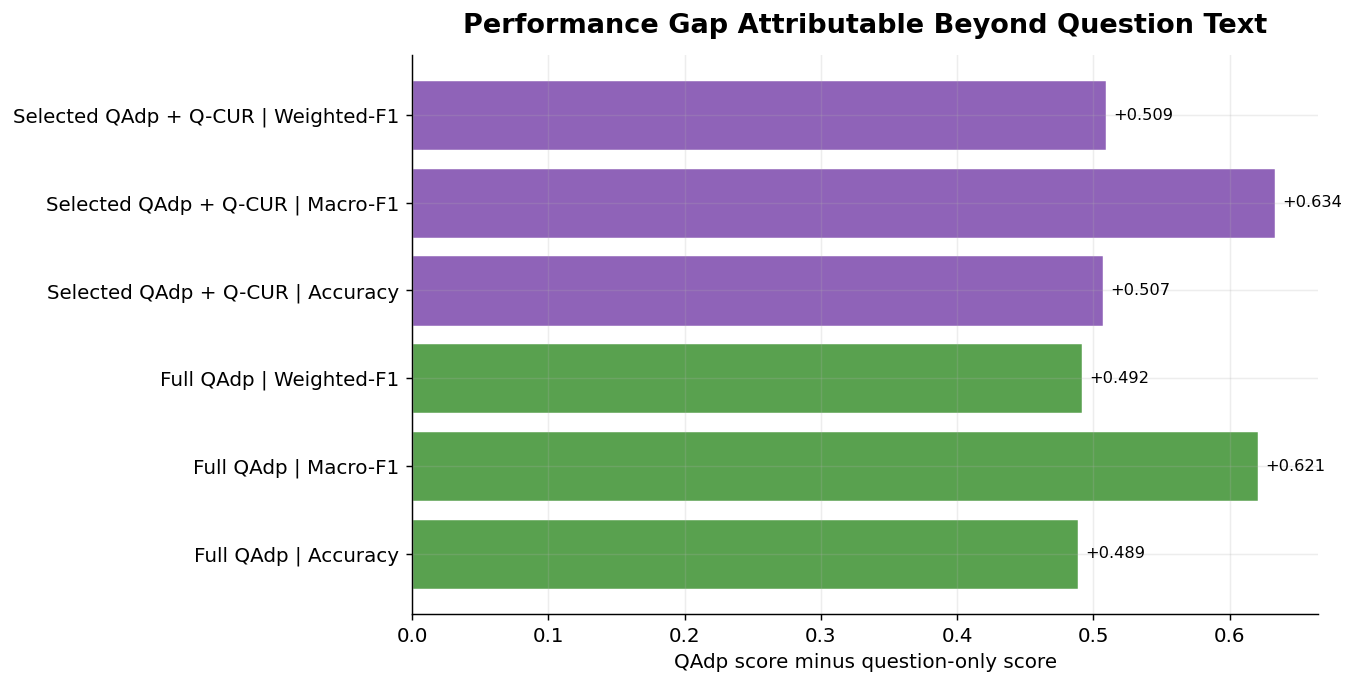

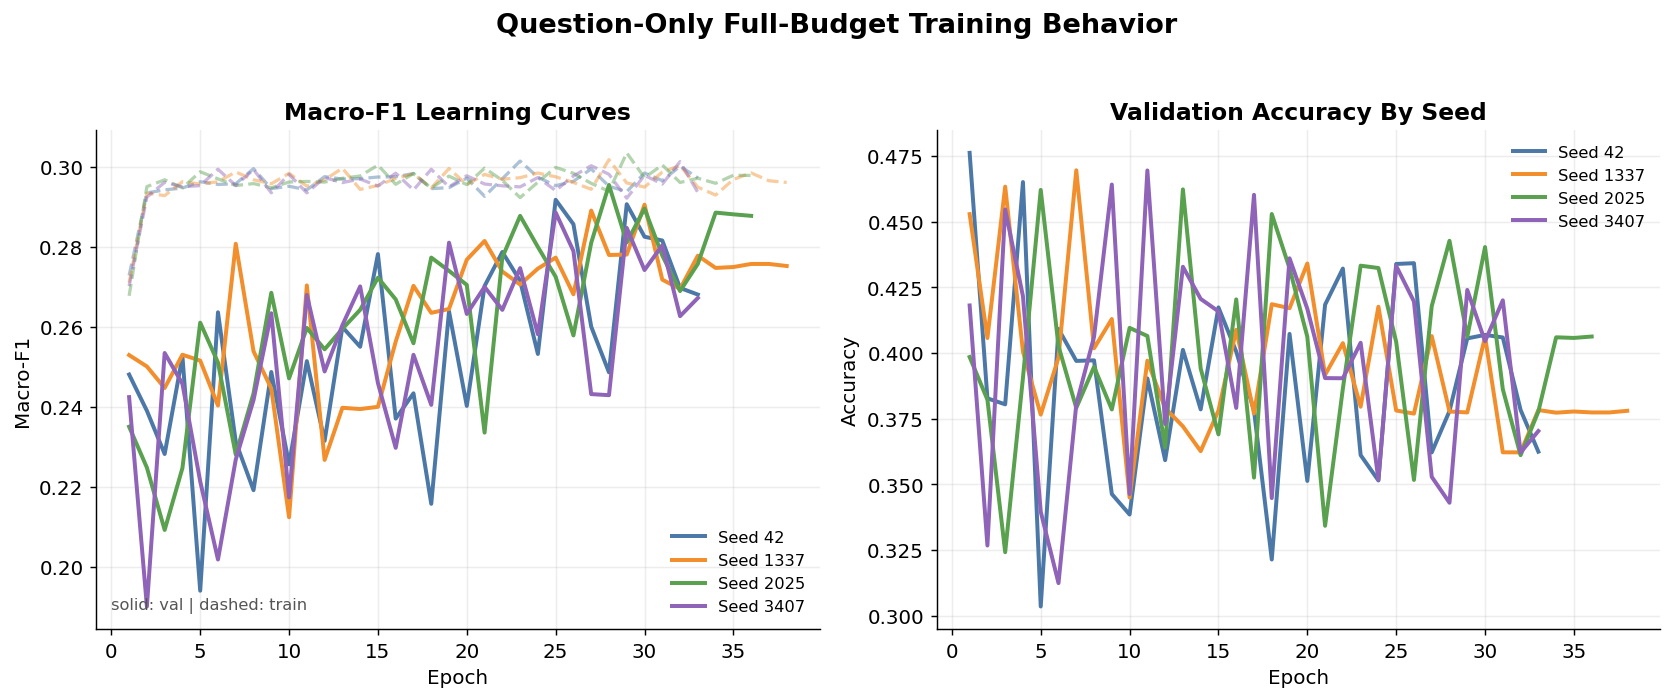

,metric_comparison,gap_bars,training_curves
0,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...,/content/drive/MyDrive/AMIR Lab/Research Assis...


In [13]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COLOR_MAP = {
    "QAdp-PRUGTM Question-Only": "#4c78a8",
    "Full QAdp-PRUGTM-Hybrid": "#59a14f",
    "Selected QAdp-PRUGTM-Hybrid + Q-CUR": "#8f63b8",
}
METRIC_LABELS = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
    "weighted_f1": "Weighted-F1",
}

comparison_fig_path = FIGURES_DIR / "question_only_vs_full_qadp_metric_comparison.png"
gap_fig_path = FIGURES_DIR / "question_only_vs_full_qadp_gap_bars.png"
training_curve_fig_path = FIGURES_DIR / "question_only_training_curves_by_seed.png"

plot_rows = comparison_df.copy()
metric_cols = [f"test_{metric}_mean" for metric in METRIC_LABELS]
plot_rows = plot_rows.dropna(subset=metric_cols, how="all")

if len(plot_rows):
    x = np.arange(len(METRIC_LABELS))
    width = min(0.22, 0.75 / max(len(plot_rows), 1))
    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    for idx, (_, row) in enumerate(plot_rows.iterrows()):
        offset = (idx - (len(plot_rows) - 1) / 2) * width
        values = [float(row.get(f"test_{metric}_mean", np.nan)) for metric in METRIC_LABELS]
        label = str(row["model_label"])
        bars = ax.bar(
            x + offset,
            values,
            width=width,
            label=label,
            color=MODEL_COLOR_MAP.get(label, "#6f6f6f"),
            edgecolor="white",
            linewidth=0.8,
        )
        ax.bar_label(bars, labels=[f"{v:.3f}" if np.isfinite(v) else "" for v in values], padding=3, fontsize=9)
    ax.set_title("Question-Only Control vs Full QAdp", fontsize=15, weight="bold", pad=12)
    ax.set_ylabel("Test score")
    ax.set_xticks(x)
    ax.set_xticklabels([METRIC_LABELS[m] for m in METRIC_LABELS])
    ax.set_ylim(0, min(1.05, max(1.0, np.nanmax(plot_rows[metric_cols].to_numpy(dtype=float)) + 0.08)))
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=1)
    fig.tight_layout()
    fig.savefig(comparison_fig_path, bbox_inches="tight")
    plt.show()

if len(gap_df):
    gap_plot_df = gap_df.copy()
    gap_plot_df["metric_label"] = gap_plot_df["metric"].map(METRIC_LABELS).fillna(gap_plot_df["metric"])
    gap_plot_df["reference_short"] = gap_plot_df["reference_model_label"].str.replace("QAdp-PRUGTM-Hybrid", "QAdp", regex=False)
    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    y_labels = gap_plot_df["reference_short"] + " | " + gap_plot_df["metric_label"]
    colors = ["#59a14f" if "Full" in label else "#8f63b8" for label in gap_plot_df["reference_model_label"]]
    bars = ax.barh(y=np.arange(len(gap_plot_df)), width=gap_plot_df["qadp_minus_question_only"], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_yticks(np.arange(len(gap_plot_df)))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("QAdp score minus question-only score")
    ax.set_title("Performance Gap Attributable Beyond Question Text", fontsize=15, weight="bold", pad=12)
    ax.axvline(0, color="#333333", linewidth=1.0)
    ax.bar_label(bars, labels=[f"{v:+.3f}" for v in gap_plot_df["qadp_minus_question_only"]], padding=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(gap_fig_path, bbox_inches="tight")
    plt.show()

history_frames = []
for _, run_row in run_summary_df.iterrows():
    seed = int(run_row["seed"])
    raw_history_path = run_row.get("training_history_path", None)
    if raw_history_path is None or pd.isna(raw_history_path):
        history_path = PHASE4_PARENT_DIR / f"seed_{seed}" / "tables" / "training_history.csv"
    else:
        history_path = Path(raw_history_path)
    if not history_path.exists():
        continue
    hist = pd.read_csv(history_path)
    hist["seed"] = seed
    history_frames.append(hist)

if history_frames:
    history_df = pd.concat(history_frames, ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2), sharex=True)
    seed_colors = ["#4c78a8", "#f28e2b", "#59a14f", "#8f63b8", "#e15759", "#76b7b2"]
    for color_idx, (seed, sub) in enumerate(history_df.groupby("seed")):
        sub = sub.sort_values("epoch")
        color = seed_colors[color_idx % len(seed_colors)]
        axes[0].plot(sub["epoch"], sub["train_macro_f1"], color=color, linewidth=1.8, alpha=0.45, linestyle="--")
        axes[0].plot(sub["epoch"], sub["val_macro_f1"], color=color, linewidth=2.2, label=f"Seed {seed}")
        axes[1].plot(sub["epoch"], sub["val_accuracy"], color=color, linewidth=2.2, label=f"Seed {seed}")
    axes[0].set_title("Macro-F1 Learning Curves", fontsize=13, weight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Macro-F1")
    axes[0].legend(frameon=False, fontsize=9)
    axes[0].text(0.02, 0.04, "solid: val | dashed: train", transform=axes[0].transAxes, fontsize=9, color="#555555")
    axes[1].set_title("Validation Accuracy By Seed", fontsize=13, weight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(frameon=False, fontsize=9)
    fig.suptitle("Question-Only Full-Budget Training Behavior", fontsize=15, weight="bold", y=1.03)
    fig.tight_layout()
    fig.savefig(training_curve_fig_path, bbox_inches="tight")
    plt.show()

figure_manifest = {
    "created_at": now_string(),
    "figures": {
        "metric_comparison": str(comparison_fig_path) if comparison_fig_path.exists() else None,
        "gap_bars": str(gap_fig_path) if gap_fig_path.exists() else None,
        "training_curves": str(training_curve_fig_path) if training_curve_fig_path.exists() else None,
    },
    "interpretation_note": (
        "The question-only control quantifies text-only shortcut risk; a large gap to full QAdp supports the "
        "value of visual and uncertainty-guided inputs, but does not establish bias-free behavior."
    ),
}
atomic_write_json(PHASE4_PARENT_DIR / "reports" / "question_only_core_figure_manifest.json", figure_manifest)
display(pd.DataFrame([figure_manifest["figures"]]))

## Slice-Level Question-Only Diagnostics

In [16]:
slice_rows = []
for _, run_row in run_summary_df.iterrows():
    seed = int(run_row["seed"])
    pred_path = Path(run_row["test_predictions_path"])
    pred_df = pd.read_csv(pred_path)
    for col in [c for c in AUDIT_REPORTING_FIELDS if c in pred_df.columns]:
        for value, sub in pred_df.groupby(col, dropna=False):
            if len(sub) < 20:
                continue
            metrics = compute_metrics(sub["gold_answer"].astype(str), sub["predicted_answer"].astype(str))
            slice_rows.append(
                {
                    "seed": seed,
                    "slice_column": col,
                    "slice_value": value,
                    "rows": int(len(sub)),
                    **metrics,
                }
            )

slice_run_df = pd.DataFrame(slice_rows)
atomic_write_csv(PHASE4_PARENT_DIR / "tables" / "question_only_slice_run_level_metrics.csv", slice_run_df)

slice_agg_rows = []
for keys, sub in slice_run_df.groupby(["slice_column", "slice_value"]):
    slice_column, slice_value = keys
    row = {
        "slice_column": slice_column,
        "slice_value": slice_value,
        "num_runs": int(len(sub)),
        "rows_mean": float(sub["rows"].mean()),
    }
    for metric in ["accuracy", "macro_f1", "weighted_f1"]:
        row[f"{metric}_mean"] = float(sub[metric].mean())
        row[f"{metric}_std"] = float(sub[metric].std(ddof=0))
    slice_agg_rows.append(row)

slice_agg_df = pd.DataFrame(slice_agg_rows).sort_values("macro_f1_mean", ascending=False)
atomic_write_csv(PHASE4_PARENT_DIR / "tables" / "question_only_slice_aggregated_metrics.csv", slice_agg_df)

display(slice_agg_df.head(30))
display(slice_agg_df.tail(30))

,slice_column,slice_value,num_runs,rows_mean,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
5,question_family,ambiguous_subregion_pair,4,3374.0,0.585433,0.035036,0.495818,0.010873,0.618876,0.025064
15,question_family,uncertainty_consistency_check,4,3374.0,0.842991,0.118456,0.473571,0.005624,0.830626,0.066684
12,question_family,more_uncertain_region,4,2700.0,0.510370,0.008253,0.470659,0.010115,0.470346,0.012154
19,question_style,comparative,4,5400.0,0.515417,0.004348,0.467797,0.010829,0.464879,0.011161
11,question_family,more_reliable_region,4,2700.0,0.520463,0.000802,0.433564,0.000634,0.435024,0.000654
23,region_target_primary,edema,4,12553.0,0.556162,0.027917,0.384781,0.009298,0.562611,0.018493
30,region_target_secondary,enhancing,4,7295.0,0.547361,0.018175,0.381646,0.008149,0.550698,0.014177
17,question_style,ambiguity_sensitive,4,10122.0,0.636189,0.044754,0.369651,0.003945,0.587003,0.026224
16,question_family,uncertainty_gap_bucket,4,2700.0,0.388889,0.000000,0.366729,0.000000,0.427989,0.000000
18,question_style,bucketed,4,5400.0,0.386343,0.001684,0.359171,0.000152,0.430303,0.001150


,slice_column,slice_value,num_runs,rows_mean,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
30,region_target_secondary,enhancing,4,7295.0,0.547361,0.018175,0.381646,0.008149,0.550698,0.014177
17,question_style,ambiguity_sensitive,4,10122.0,0.636189,0.044754,0.369651,0.003945,0.587003,0.026224
16,question_family,uncertainty_gap_bucket,4,2700.0,0.388889,0.000000,0.366729,0.000000,0.427989,0.000000
18,question_style,bucketed,4,5400.0,0.386343,0.001684,0.359171,0.000152,0.430303,0.001150
13,question_family,reliability_gap_bucket,4,2700.0,0.383796,0.003368,0.351012,0.000679,0.432810,0.002082
31,region_target_secondary,ncr_net,4,3929.0,0.559812,0.007274,0.328259,0.004396,0.487706,0.003049
26,region_target_primary,ncr_net,4,7516.0,0.465241,0.004386,0.326638,0.007269,0.479095,0.004592
28,region_target_secondary,context,4,5853.0,0.377926,0.003059,0.303875,0.019624,0.377928,0.016549
7,question_family,confidence_qualified_presence,4,2532.0,0.323657,0.001965,0.300301,0.012014,0.300298,0.012037
2,difficulty_level,easy,4,8554.0,0.460136,0.018511,0.285024,0.024164,0.474063,0.021998


## Final Done Marker and Quick Inspect

In [17]:
completion_report = {
    "status": "complete",
    "finished_at": now_string(),
    "phase": "Phase 04 QAdp-PRUGTM question-only clean-metadata four-seeds control",
    "output_dir": str(PHASE4_PARENT_DIR),
    "run_summary": str(PHASE4_PARENT_DIR / "tables" / "question_only_four_seed_run_summary.csv"),
    "aggregated_metrics": str(PHASE4_PARENT_DIR / "tables" / "question_only_four_seed_aggregated_metrics.csv"),
    "comparison": str(PHASE4_PARENT_DIR / "tables" / "question_only_vs_full_qadp_comparison.csv"),
    "input_policy_report": str(PHASE4_PARENT_DIR / "reports" / "question_only_input_policy_report.json"),
    "figures": {
        "metric_comparison": str(FIGURES_DIR / "question_only_vs_full_qadp_metric_comparison.png"),
        "gap_bars": str(FIGURES_DIR / "question_only_vs_full_qadp_gap_bars.png"),
        "training_curves": str(FIGURES_DIR / "question_only_training_curves_by_seed.png"),
    },
    "interpretation_note": (
        "Question-only control quantifies text-only shortcut risk. A large full-QAdp gap supports value from "
        "visual/uncertainty-guided inputs, but should not be described as bias-free behavior."
    ),
}
atomic_write_json(PHASE4_PARENT_DIR / "done" / "question_only_four_seed_complete.json", completion_report)

print("Tables:")
for path in sorted((PHASE4_PARENT_DIR / "tables").glob("*.csv")):
    print(" -", path.name)
print("\nReports:")
for path in sorted((PHASE4_PARENT_DIR / "reports").glob("*.json")):
    print(" -", path.name)
print("\nFigures:")
for path in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", path.name)
print("\nSeed prediction files:")
for path in sorted(PHASE4_PARENT_DIR.glob("seed_*/predictions/test_predictions.csv")):
    print(" -", path)
print("\nDone:", PHASE4_PARENT_DIR / "done" / "question_only_four_seed_complete.json")

Tables:
 - question_only_four_seed_aggregated_metrics.csv
 - question_only_four_seed_run_summary.csv
 - question_only_slice_aggregated_metrics.csv
 - question_only_slice_run_level_metrics.csv
 - question_only_vs_full_qadp_comparison.csv
 - question_only_vs_full_qadp_gap_metrics.csv

Reports:
 - question_only_core_figure_manifest.json
 - question_only_input_policy_report.json
 - question_only_load_manifest.json
 - question_only_vs_full_qadp_interpretation.json

Figures:
 - question_only_training_curves_by_seed.png
 - question_only_vs_full_qadp_gap_bars.png
 - question_only_vs_full_qadp_metric_comparison.png

Seed prediction files:
 - /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/qadp_prugtm_question_only_btumqa_four_seeds/seed_1337/predictions/test_predictions.csv
 - /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_traini